# Edge Online learning for watrer level prediction

In [ ]:
import torch.optim as optim
import pandas as pd
import numpy as np
import util_fun as uf
from cstm_models import build_mlp 

### Training parameter

In [2]:
# --- Define Model Parameters ---
LOOKBACK = 48   # 48 hours of historical data
HORIZON = 24    # 24 hours of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  # we are using batch size of 1 for time series
H_BAR_INDEX = 3 # H_bar is the 4th feature (index 3)
EPSILON = 1e-6  # For numerical stability in normalization



In [5]:
train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by oytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)



<class 'pandas.core.frame.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)


## Online Training using ADAM


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.007509
   Batch 200/2461, Loss: 0.001247
   Batch 300/2461, Loss: 0.134097
   Batch 400/2461, Loss: 0.051238
   Batch 500/2461, Loss: 0.017649
   Batch 600/2461, Loss: 0.315726
   Batch 700/2461, Loss: 0.035791
   Batch 800/2461, Loss: 0.003522
   Batch 900/2461, Loss: 0.201027
   Batch 1000/2461, Loss: 0.157824
   Batch 1100/2461, Loss: 0.031532
   Batch 1200/2461, Loss: 0.062087
   Batch 1300/2461, Loss: 0.004699
   Batch 1400/2461, Loss: 0.121815
   Batch 1500/2461, Loss: 0.018767
   Batch 1600/2461, Loss: 0.065692
   Batch 1700/2461, Loss: 0.032414
   Batch 1800/2461, Loss: 0.068747
   Batch 1900/2461, Loss: 0.072877
   Batch 2000/2461, Loss: 0.092291
   Batch 2100/2461, Loss: 0.038285
   Batch 2200/2461, Loss: 0.021642
   Batch 2300/2461, Loss: 0.101209
   Batch 2400/2461, Loss: 0.006416
   Batch 2461/2461, Loss: 0.027690
Training complete.


============== FINAL COMPARISON ==============
online-ADAM      

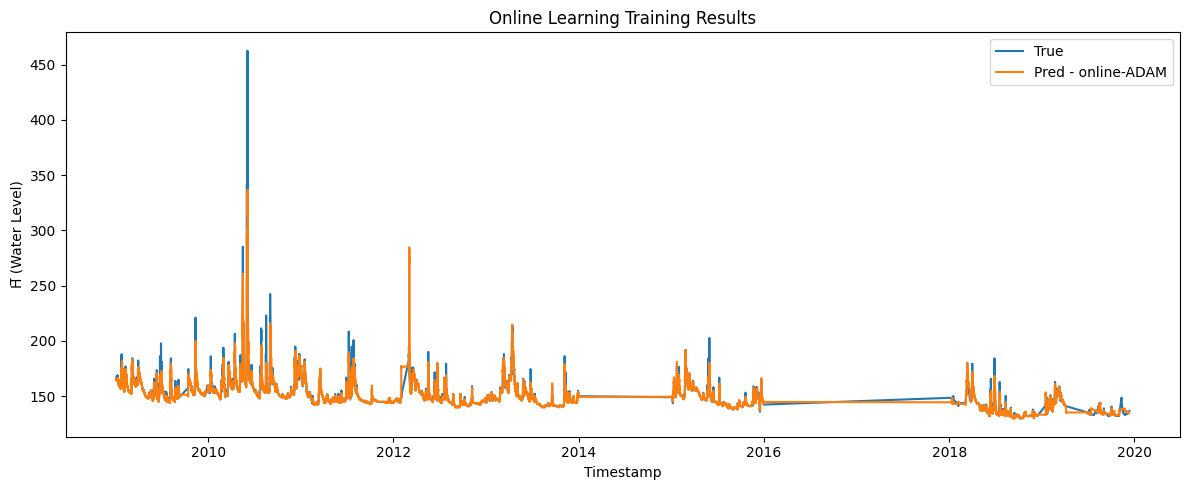

Saved matplotlib PNG: results/training\Online Learning Training Results.png
Appended metrics to CSV: results/training\Online Learning Training Results.csv


In [6]:
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Online Learning Training Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/training/Online Learning Training Results')

Testing complete.


============== FINAL COMPARISON ==============
online-ADAM          | RMSE=5.1112 | MAE=1.4376 | R²=0.8024


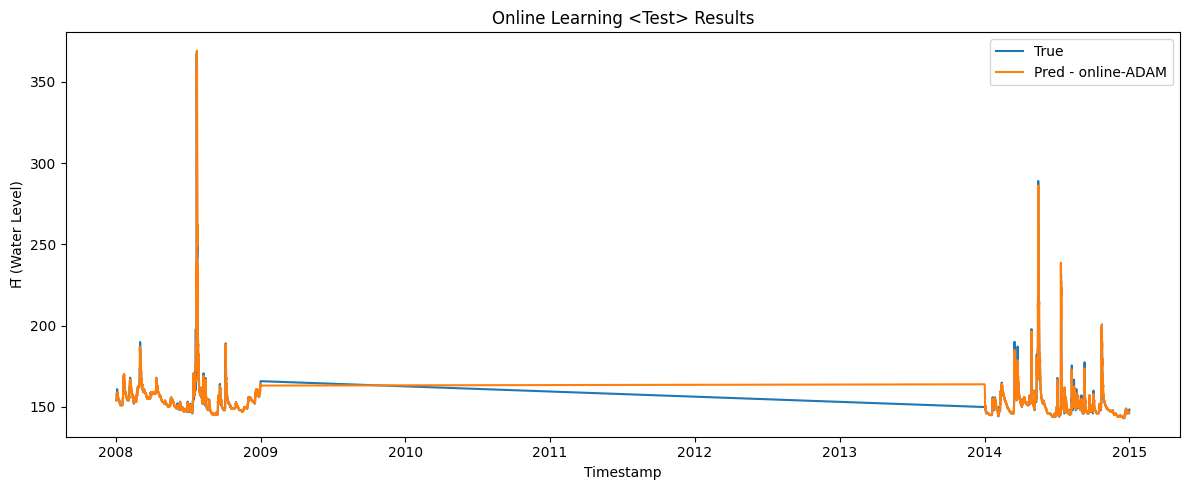

Saved matplotlib PNG: results/testing\Online Learning ADAM Testing Results.png
Appended metrics to CSV: results/testing\Online Learning ADAM Testing Results.csv


In [7]:
# evaluation on test set
y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
uf.calculate_metrics_and_plot({"online-ADAM": (y_true_test, y_pred_test, time_indices_test)},
                              plot_title = 'Online Learning <Test> Results',
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/testing/Online Learning ADAM Testing Results')
    


Starting 'online' training with 728 batches...
   Batch 100/728, Loss: 0.113030
   Batch 200/728, Loss: 0.147371
   Batch 300/728, Loss: 0.487137
   Batch 400/728, Loss: 0.174713
   Batch 500/728, Loss: 0.004890
   Batch 600/728, Loss: 0.011345
   Batch 700/728, Loss: 0.014325
   Batch 728/728, Loss: 0.178542
Training complete.


============== FINAL COMPARISON ==============
online-ADAM          | RMSE=4.4094 | MAE=1.3719 | R²=0.8529


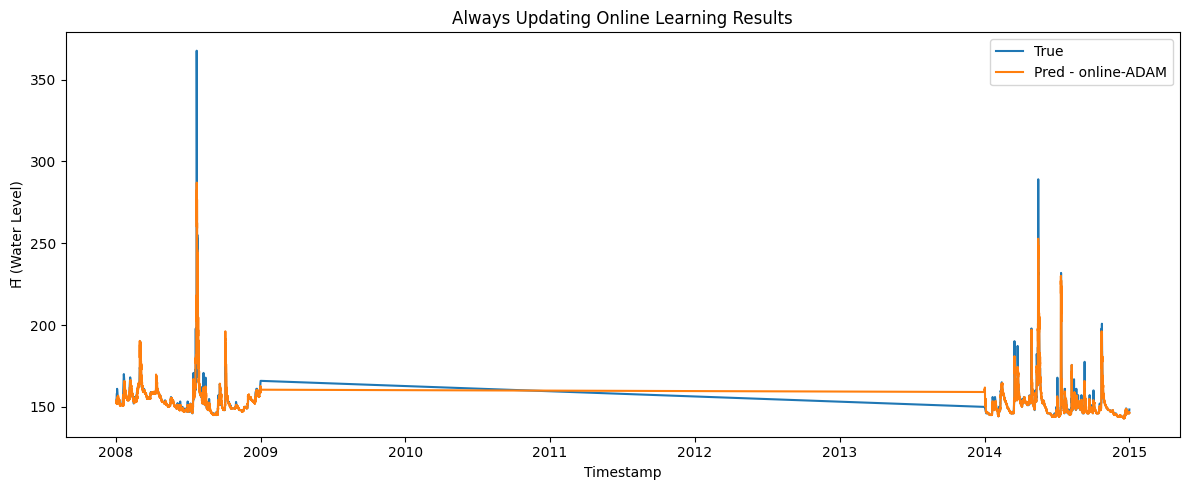

Saved matplotlib PNG: results\Online Learning always updating Results 2.png
Appended metrics to CSV: results\Online Learning always updating Results 2.csv


In [9]:
# Testing with always updating 
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              test_ds, test_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Always Updating Online Learning Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/Online Learning always updating Results 2')

## Learning rate comparison


Training with optimizer: Adam

Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.007381
   Batch 200/2461, Loss: 0.000687
   Batch 300/2461, Loss: 0.141468
   Batch 400/2461, Loss: 0.057197
   Batch 500/2461, Loss: 0.015841
   Batch 600/2461, Loss: 0.315029
   Batch 700/2461, Loss: 0.035134
   Batch 800/2461, Loss: 0.002958
   Batch 900/2461, Loss: 0.213995
   Batch 1000/2461, Loss: 0.163419
   Batch 1100/2461, Loss: 0.028596
   Batch 1200/2461, Loss: 0.057724
   Batch 1300/2461, Loss: 0.001194
   Batch 1400/2461, Loss: 0.131252
   Batch 1500/2461, Loss: 0.021691
   Batch 1600/2461, Loss: 0.064461
   Batch 1700/2461, Loss: 0.035248
   Batch 1800/2461, Loss: 0.071957
   Batch 1900/2461, Loss: 0.065843
   Batch 2000/2461, Loss: 0.077217
   Batch 2100/2461, Loss: 0.034867
   Batch 2200/2461, Loss: 0.021335
   Batch 2300/2461, Loss: 0.092032
   Batch 2400/2461, Loss: 0.005407
   Batch 2461/2461, Loss: 0.028164
Training complete.

Training with optimizer: AdamW

St

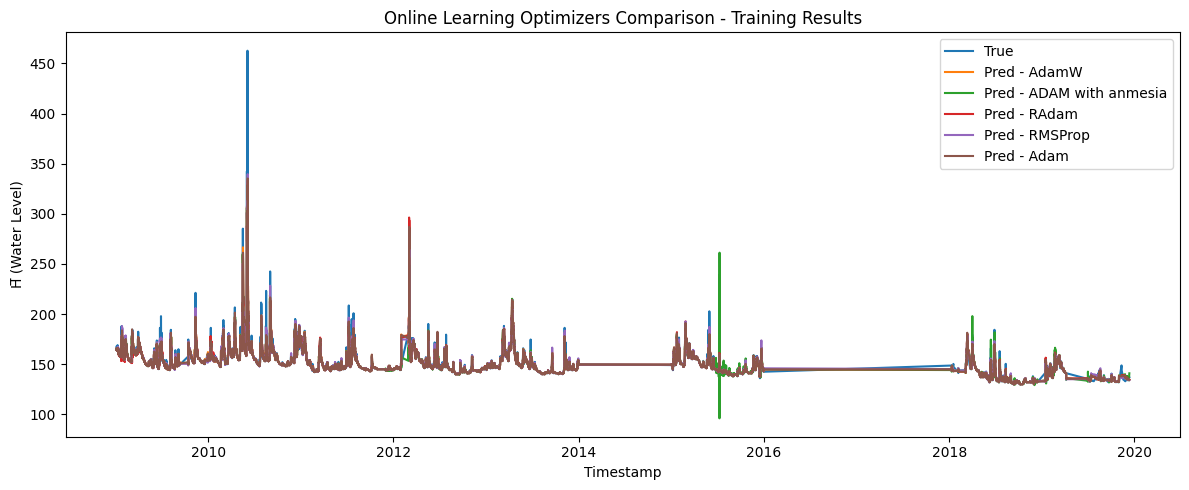

Saved matplotlib PNG: results/training\Online Learning Optimizers Comparison - Training Results.png
Appended metrics to CSV: results/training\Online Learning Optimizers Comparison - Training Results.csv


In [12]:
# ---- List of Optimizers to Compare ----------------------------

def build_optimizers(model, lr=0.001):
    return {
        "Adam": optim.Adam(model.parameters(), lr=lr),
        "AdamW": optim.AdamW(model.parameters(), lr=lr),
        "RMSProp": optim.RMSprop(model.parameters(), lr=lr, alpha=0.9),
        "RAdam": optim.RAdam(model.parameters(), lr=lr),
        "ADAM with anmesia": optim.Adam(model.parameters(), lr=lr),
    }

results = {}
models_after_training = {}
optimizers_to_test = ["Adam", "AdamW", "RMSProp", "RAdam", "ADAM with anmesia"]
for opt_name in optimizers_to_test:
    print(f"\n==============================")
    print(f"Training with optimizer: {opt_name}")
    print(f"==============================")

    # Reinitialize a fresh model for each optimizer
    # create a new instance of the MLP model with adam them overwriting the optimizer by bild_optimizers call
    model_temp, _, criterion = build_mlp(LOOKBACK * N_FEATURES, HORIZON) 
    opt_dict = build_optimizers(model_temp)

    optimizer = opt_dict[opt_name]

    if opt_name == "ADAM with anmesia":
        enable_amnesia = True
    else:
        enable_amnesia = False
        
    y_true, y_pred, time_indices, batch_losses = uf.train_model_online(model_temp, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE,
                                                                              enable_amnesia, 7, 50, 0.1, 0.001)
    results[opt_name] = (y_true, y_pred, time_indices)
    models_after_training[opt_name] = model_temp
uf.calculate_metrics_and_plot(results,'Online Learning Optimizers Comparison - Training Results',
                              export_metrics= True,
                              export_file_name='results/training/Online Learning Optimizers Comparison - Training Results')



Evaluating model trained with optimizer: Adam
Testing complete.

Evaluating model trained with optimizer: AdamW
Testing complete.

Evaluating model trained with optimizer: RMSProp
Testing complete.

Evaluating model trained with optimizer: RAdam
Testing complete.

Evaluating model trained with optimizer: ADAM with anmesia
Testing complete.


============== FINAL COMPARISON ==============
Adam                 | RMSE=5.1477 | MAE=1.4550 | R²=0.7995
AdamW                | RMSE=5.2159 | MAE=1.4477 | R²=0.7942
RMSProp              | RMSE=4.1639 | MAE=1.2380 | R²=0.8688
RAdam                | RMSE=5.2033 | MAE=1.4676 | R²=0.7952
ADAM with anmesia    | RMSE=4.8782 | MAE=1.5334 | R²=0.8200


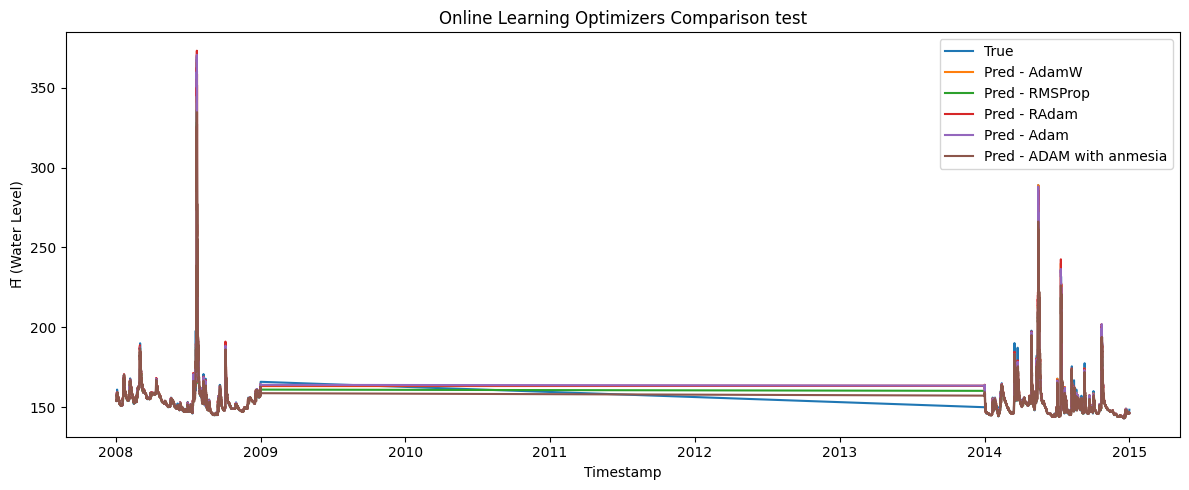

Saved matplotlib PNG: results/testing\optimizers_comparison_test.png
Appended metrics to CSV: results/testing\optimizers_comparison_test.csv


In [13]:
results = {}
for opt_name, model in models_after_training.items():
    print(f"\n==============================")
    print(f"Evaluating model trained with optimizer: {opt_name}")
    print(f"==============================")
    
    y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
    results[opt_name] = (y_true_test, y_pred_test, time_indices_test)
uf.calculate_metrics_and_plot(results,'Online Learning Optimizers Comparison test',
                              export_metrics= True,
                              export_html=True,
                              export_file_name= 'results/testing/optimizers_comparison_test')